In [62]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

In [63]:
from tensorflow.keras.datasets import fashion_mnist

In [64]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

In [65]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [66]:
x_train = np.expand_dims(x_train, -1)   
x_test = np.expand_dims(x_test, -1)

In [67]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [68]:
model = Sequential([
    Conv2D(32, (3,3), padding = "same", 
           activation = 'relu',
           strides=2,
           input_shape = (28,28,1)),
           MaxPooling2D((2, 2)),
           Conv2D(64, (3, 3), activation='relu'),
           MaxPooling2D((2, 2)),
           Conv2D(64, (3, 3), padding='same',  activation='relu'),
           Flatten(),
           Dense(64, activation='relu'),
           Dense(10, activation='softmax')
       ])            

In [69]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [70]:
model.fit(
        x = x_train,
        y = y_train,
        batch_size = 16,
        epochs = 5,
#        verbose = 0,
        shuffle=False,
        validation_split = 0.1
        )

Epoch 1/5
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 54s 13ms/step - accuracy: 0.7994 - loss: 0.5399 - val_accuracy: 0.8513 - val_loss: 0.3867
Epoch 2/5
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 46s 13ms/step - accuracy: 0.8677 - loss: 0.3585 - val_accuracy: 0.8698 - val_loss: 0.3373
Epoch 3/5
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - accuracy: 0.8835 - loss: 0.3112 - val_accuracy: 0.8793 - val_loss: 0.3196
Epoch 4/5
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 50s 15ms/step - accuracy: 0.8964 - loss: 0.2798 - val_accuracy: 0.8805 - val_loss: 0.3171
Epoch 5/5
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - accuracy: 0.9053 - loss: 0.2540 - val_accuracy: 0.8808 - val_loss: 0.3231


In [95]:
img = x_train[1]
img_batch = np.expand_dims(img, axis=0)

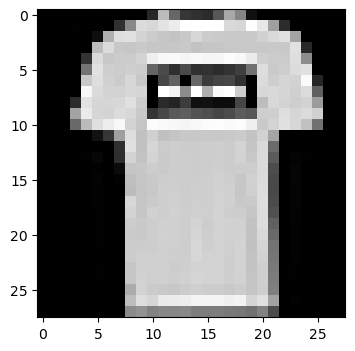

In [96]:
plt.figure(figsize=(4, 4))
plt.imshow(img.squeeze(), cmap='gray')
plt.show()

In [97]:
pred = model.predict(img_batch) 
pred_class = np.argmax(pred)    

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


In [98]:
from tensorflow.keras.models import Model

In [99]:
first_layer_output = model.layers[1].output

In [ ]:
# py torch

In [101]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split